# Exercice 2 — Incidents, maintenance et alignement temporel

## Objectif concret

Ce notebook poursuit l'alimentation du niveau **Bronze**, produit un jeu d'incidents **Silver** sans les trois colonnes humaines inutiles, puis cherche à retracer l'histoire commune des incidents et des maintenances avec `matplotlib`.

Une **granularité temporelle** est la durée utilisée pour regrouper des événements. Nous utiliserons le mois pour la vue annuelle et une fenêtre de 30 jours avant/après chaque maintenance pour préserver l'ordre des événements.

Une **corrélation** mesure l'association entre deux variables ; elle ne démontre pas qu'une variable cause l'autre. La corrélation de **Spearman** mesure si les deux variables évoluent globalement dans le même ordre, sans exiger une relation parfaitement linéaire.

### Prérequis et point de départ observable

- exécuter le notebook depuis la racine du projet `indusense` ;
- disposer de `datas/machine.csv` et `datas/releves_incidents.csv.csv` ;
- utiliser l'environnement UV du projet, qui contient `pandas`, `tabulate` et `matplotlib`.

La cellule suivante importe les bibliothèques, vérifie les deux sources et mémorise leur empreinte SHA-256. Cette empreinte permettra de confirmer à la fin que les fichiers Bronze n'ont pas été modifiés.

In [1]:
from hashlib import sha256
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython import get_ipython
from tabulate import tabulate

get_ipython().run_line_magic("matplotlib", "inline")

DOSSIER_DONNEES = Path("datas")
CHEMIN_MACHINES = DOSSIER_DONNEES / "machine.csv"
CHEMIN_INCIDENTS = DOSSIER_DONNEES / "releves_incidents.csv.csv"
CHEMIN_SILVER = Path("outputs") / "silver" / "releves_incidents_silver.csv"

for chemin in (CHEMIN_MACHINES, CHEMIN_INCIDENTS):
    assert chemin.exists(), f"Fichier introuvable : {chemin}"


def empreinte_fichier(chemin):
    # Calcule une empreinte stable sans modifier le fichier.
    return sha256(chemin.read_bytes()).hexdigest()


empreintes_bronze_initiales = {
    chemin.name: empreinte_fichier(chemin)
    for chemin in (CHEMIN_MACHINES, CHEMIN_INCIDENTS)
}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

print("Sources Bronze trouvées :")
for chemin in (CHEMIN_MACHINES, CHEMIN_INCIDENTS):
    print(f"- {chemin} ({chemin.stat().st_size:,} octets)")

Sources Bronze trouvées :
- datas\machine.csv (22,654 octets)
- datas\releves_incidents.csv.csv (137,869 octets)


## 1. Explorer `machine.csv` dans le Bronze

Le niveau **Bronze** conserve la donnée au plus près de sa forme source. Nous chargeons donc `machine.csv` sans écraser le fichier et nous observons les types détectés automatiquement par pandas.

Le fichier mélange deux familles d'informations :

- le profil relativement stable de la machine (`model`, `production_line`, `criticality`, etc.) ;
- les événements de maintenance (`maintenance_at`, `maintenance_type`, `component`, etc.).

La cellule suivante affiche les dimensions, les types et dix lignes limitées aux colonnes non humaines. Le résultat attendu est un tableau de 115 lignes et 17 colonnes.

In [2]:
machines_bronze = pd.read_csv(CHEMIN_MACHINES)

colonnes_apercu_machine = [
    "maintenance_id",
    "machine_code",
    "model",
    "production_line",
    "criticality",
    "maintenance_at",
    "maintenance_type",
    "component",
    "duration_hours",
]

print(f"Dimensions de machine.csv : {machines_bronze.shape}")
print("\nTypes détectés dans le Bronze :")
print(machines_bronze.dtypes.to_string())
print("\nDix premières maintenances :")
print(
    tabulate(
        machines_bronze[colonnes_apercu_machine].head(10),
        headers="keys",
        tablefmt="rounded_outline",
        showindex=False,
    )
)

Dimensions de machine.csv : (115, 17)

Types détectés dans le Bronze :
maintenance_id                  int64
machine_code                      str
commissioning_date                str
max_daily_capacity              int64
max_hourly_capacity_pieces      int64
model                             str
production_line                   str
location                          str
criticality                       str
is_active                        bool
maintenance_at                    str
maintenance_type                  str
action_type                       str
component                         str
description                       str
related_incident_id               str
duration_hours                float64

Dix premières maintenances :
╭──────────────────┬────────────────┬──────────────┬───────────────────┬───────────────┬────────────────────────┬────────────────────┬─────────────────────────┬──────────────────╮
│   maintenance_id │ machine_code   │ model        │ production_line   │ 

## 2. Contrôler la qualité et la structure métier des maintenances

Une **clé** est une colonne utilisée pour identifier ou rapprocher des lignes. Ici, `maintenance_id` doit identifier une maintenance et `machine_code` doit correspondre au `machine_id` des incidents.

`maintenance_at` contient explicitement le décalage `+00`, donc ces horodatages sont en **UTC** (*Coordinated Universal Time*), référence temporelle internationale.

La cellule suivante vérifie les doublons, les valeurs manquantes, la stabilité du profil de chaque machine et la répartition proactive/réactive. Une incohérence provoquera une assertion visible au lieu d'être ignorée.

In [3]:
machines_analyse = machines_bronze.copy()
machines_analyse["maintenance_at_utc"] = pd.to_datetime(
    machines_analyse["maintenance_at"], errors="raise", utc=True
)

colonnes_profil_machine = [
    "commissioning_date",
    "max_daily_capacity",
    "max_hourly_capacity_pieces",
    "model",
    "production_line",
    "location",
    "criticality",
    "is_active",
]

assert machines_analyse["maintenance_id"].is_unique
assert machines_analyse["machine_code"].nunique() == 15
assert (
    machines_analyse.groupby("machine_code")[colonnes_profil_machine]
    .nunique(dropna=False)
    .le(1)
    .all()
    .all()
), "Le profil d'au moins une machine varie entre deux maintenances."

qualite_machines = pd.DataFrame(
    {
        "indicateur": [
            "Nombre de maintenances",
            "Machines distinctes",
            "Identifiants dupliqués",
            "Maintenances proactives",
            "Maintenances réactives",
            "Liens vers un incident",
            "Début des maintenances UTC",
            "Fin des maintenances UTC",
        ],
        "valeur": [
            len(machines_analyse),
            machines_analyse["machine_code"].nunique(),
            machines_analyse["maintenance_id"].duplicated().sum(),
            machines_analyse["maintenance_type"].eq("proactive").sum(),
            machines_analyse["maintenance_type"].eq("reactive").sum(),
            machines_analyse["related_incident_id"].notna().sum(),
            machines_analyse["maintenance_at_utc"].min(),
            machines_analyse["maintenance_at_utc"].max(),
        ],
    }
)

print(tabulate(qualite_machines, headers="keys", tablefmt="rounded_outline", showindex=False))
print("\nValeurs manquantes :")
print(machines_bronze.isna().sum().loc[lambda serie: serie.gt(0)].to_string())

╭────────────────────────────┬───────────────────────────╮
│ indicateur                 │ valeur                    │
├────────────────────────────┼───────────────────────────┤
│ Nombre de maintenances     │ 115                       │
│ Machines distinctes        │ 15                        │
│ Identifiants dupliqués     │ 0                         │
│ Maintenances proactives    │ 90                        │
│ Maintenances réactives     │ 25                        │
│ Liens vers un incident     │ 25                        │
│ Début des maintenances UTC │ 2025-06-15 06:00:00+00:00 │
│ Fin des maintenances UTC   │ 2026-05-30 22:00:00+00:00 │
╰────────────────────────────┴───────────────────────────╯

Valeurs manquantes :
related_incident_id    90


## 3. Produire le dataset Silver non directement identifiable

Le niveau **Silver** contient des données nettoyées, typées et protégées pour l'usage prévu. Le besoin porte sur les machines, les incidents et les maintenances, pas sur les opérateurs.

Nous appliquons donc le principe de **minimisation** : supprimer les données personnelles qui ne sont pas nécessaires. Les colonnes retirées sont `operator_name`, `operator_badge` et `comment`.

Cette décision rend le jeu non directement identifiable dans le périmètre du TP. Elle ne constitue pas à elle seule une preuve juridique d'anonymisation irréversible : un horodatage précis et une machine pourraient encore être rapprochés d'un planning détenu ailleurs.

La cellule suivante crée une copie Silver, convertit les dates et les indicateurs `type_*`, l'exporte dans `outputs/silver/`, puis relit le CSV pour vérifier réellement son schéma. Le Bronze reste inchangé.

In [4]:
incidents_bronze = pd.read_csv(CHEMIN_INCIDENTS)
colonnes_supprimees = ["operator_name", "operator_badge", "comment"]
colonnes_types_incident = [
    colonne for colonne in incidents_bronze.columns if colonne.startswith("type_")
]

incidents_silver = incidents_bronze.drop(columns=colonnes_supprimees).copy()
incidents_silver["incident_at_source"] = pd.to_datetime(
    incidents_silver["date"].astype("string")
    + " "
    + incidents_silver["time"].astype("string"),
    errors="raise",
)
incidents_silver = incidents_silver.drop(columns=["date", "time"])
incidents_silver["severity"] = incidents_silver["severity"].astype("Int64")

for colonne in colonnes_types_incident:
    valeurs = set(incidents_silver[colonne].dropna().unique())
    assert valeurs.issubset({0, 1}), f"Valeurs inattendues dans {colonne} : {valeurs}"
    incidents_silver[colonne] = incidents_silver[colonne].astype("boolean")

assert not set(colonnes_supprimees) & set(incidents_silver.columns)
assert len(incidents_silver) == len(incidents_bronze)

CHEMIN_SILVER.parent.mkdir(parents=True, exist_ok=True)
incidents_silver.to_csv(CHEMIN_SILVER, index=False)
silver_relu = pd.read_csv(CHEMIN_SILVER)

assert not set(colonnes_supprimees) & set(silver_relu.columns)
assert len(silver_relu) == len(incidents_bronze)

rapport_silver = pd.DataFrame(
    {
        "contrôle": [
            "Lignes Bronze",
            "Lignes Silver",
            "Colonnes Bronze",
            "Colonnes Silver",
            "Colonnes humaines restantes",
            "Fichier Silver créé",
        ],
        "résultat": [
            len(incidents_bronze),
            len(incidents_silver),
            len(incidents_bronze.columns),
            len(incidents_silver.columns),
            len(set(colonnes_supprimees) & set(silver_relu.columns)),
            CHEMIN_SILVER.exists(),
        ],
    }
)

print(tabulate(rapport_silver, headers="keys", tablefmt="rounded_outline", showindex=False))
print(f"\nSilver exporté vers : {CHEMIN_SILVER}")

╭─────────────────────────────┬────────────╮
│ contrôle                    │   résultat │
├─────────────────────────────┼────────────┤
│ Lignes Bronze               │       1245 │
│ Lignes Silver               │       1245 │
│ Colonnes Bronze             │         18 │
│ Colonnes Silver             │         14 │
│ Colonnes humaines restantes │          0 │
│ Fichier Silver créé         │       True │
╰─────────────────────────────┴────────────╯

Silver exporté vers : outputs\silver\releves_incidents_silver.csv


## 4. Construire deux scénarios temporels cohérents

Les incidents contiennent une date et une heure sans fuseau : ils sont **timezone-naive**. Les maintenances sont explicitement en UTC.

Nous testons deux hypothèses sans mélanger les référentiels :

1. **scénario UTC** : l'heure d'incident est supposée UTC et les maintenances restent UTC ;
2. **scénario Europe/Paris** : l'heure d'incident est supposée locale et les maintenances sont converties d'UTC vers `Europe/Paris`.

Une **hypothèse de fuseau** précise comment interpréter une heure qui ne contient pas cette information. La cellule suivante produit les deux jeux d'horodatages et vérifie que les changements d'heure français ne créent ici ni heure ambiguë ni heure inexistante.

In [5]:
horodatages_incidents_sans_fuseau = incidents_silver["incident_at_source"]

horodatages_incidents_utc = horodatages_incidents_sans_fuseau.dt.tz_localize(
    "UTC", ambiguous="raise", nonexistent="raise"
)
horodatages_incidents_paris = horodatages_incidents_sans_fuseau.dt.tz_localize(
    "Europe/Paris", ambiguous="raise", nonexistent="raise"
)

scenarios = {
    "UTC": {
        "incidents": horodatages_incidents_utc,
        "maintenances": machines_analyse["maintenance_at_utc"],
    },
    "Europe/Paris": {
        "incidents": horodatages_incidents_paris,
        "maintenances": machines_analyse["maintenance_at_utc"].dt.tz_convert("Europe/Paris"),
    },
}

comparaison_fuseaux = []
for nom, donnees in scenarios.items():
    debut_commun = max(donnees["incidents"].min(), donnees["maintenances"].min())
    fin_commune = min(donnees["incidents"].max(), donnees["maintenances"].max())
    comparaison_fuseaux.append(
        {
            "scénario": nom,
            "début commun": debut_commun,
            "fin commune": fin_commune,
            "durée commune (jours)": round((fin_commune - debut_commun).total_seconds() / 86_400, 1),
        }
    )

comparaison_fuseaux = pd.DataFrame(comparaison_fuseaux)
print(tabulate(comparaison_fuseaux, headers="keys", tablefmt="rounded_outline", showindex=False))

╭──────────────┬───────────────────────────┬───────────────────────────┬─────────────────────────╮
│ scénario     │ début commun              │ fin commune               │   durée commune (jours) │
├──────────────┼───────────────────────────┼───────────────────────────┼─────────────────────────┤
│ UTC          │ 2025-06-15 06:00:00+00:00 │ 2026-05-30 22:00:00+00:00 │                   349.7 │
│ Europe/Paris │ 2025-06-15 08:00:00+02:00 │ 2026-05-31 00:00:00+02:00 │                   349.7 │
╰──────────────┴───────────────────────────┴───────────────────────────┴─────────────────────────╯


## 5. Visualiser la distribution des incidents avec `matplotlib`

Une **distribution** montre comment les observations se répartissent entre des périodes ou des catégories.

Nous produisons quatre vues complémentaires :

- évolution mensuelle dans les deux scénarios horaires ;
- nombre d'incidents par sévérité ;
- nombre d'incidents par type ;
- nombre d'incidents par machine.

Les deux courbes temporelles permettent de voir si l'hypothèse de fuseau change l'affectation mensuelle. Les autres graphes décrivent la population complète d'incidents et ne nécessitent aucune donnée opérateur.

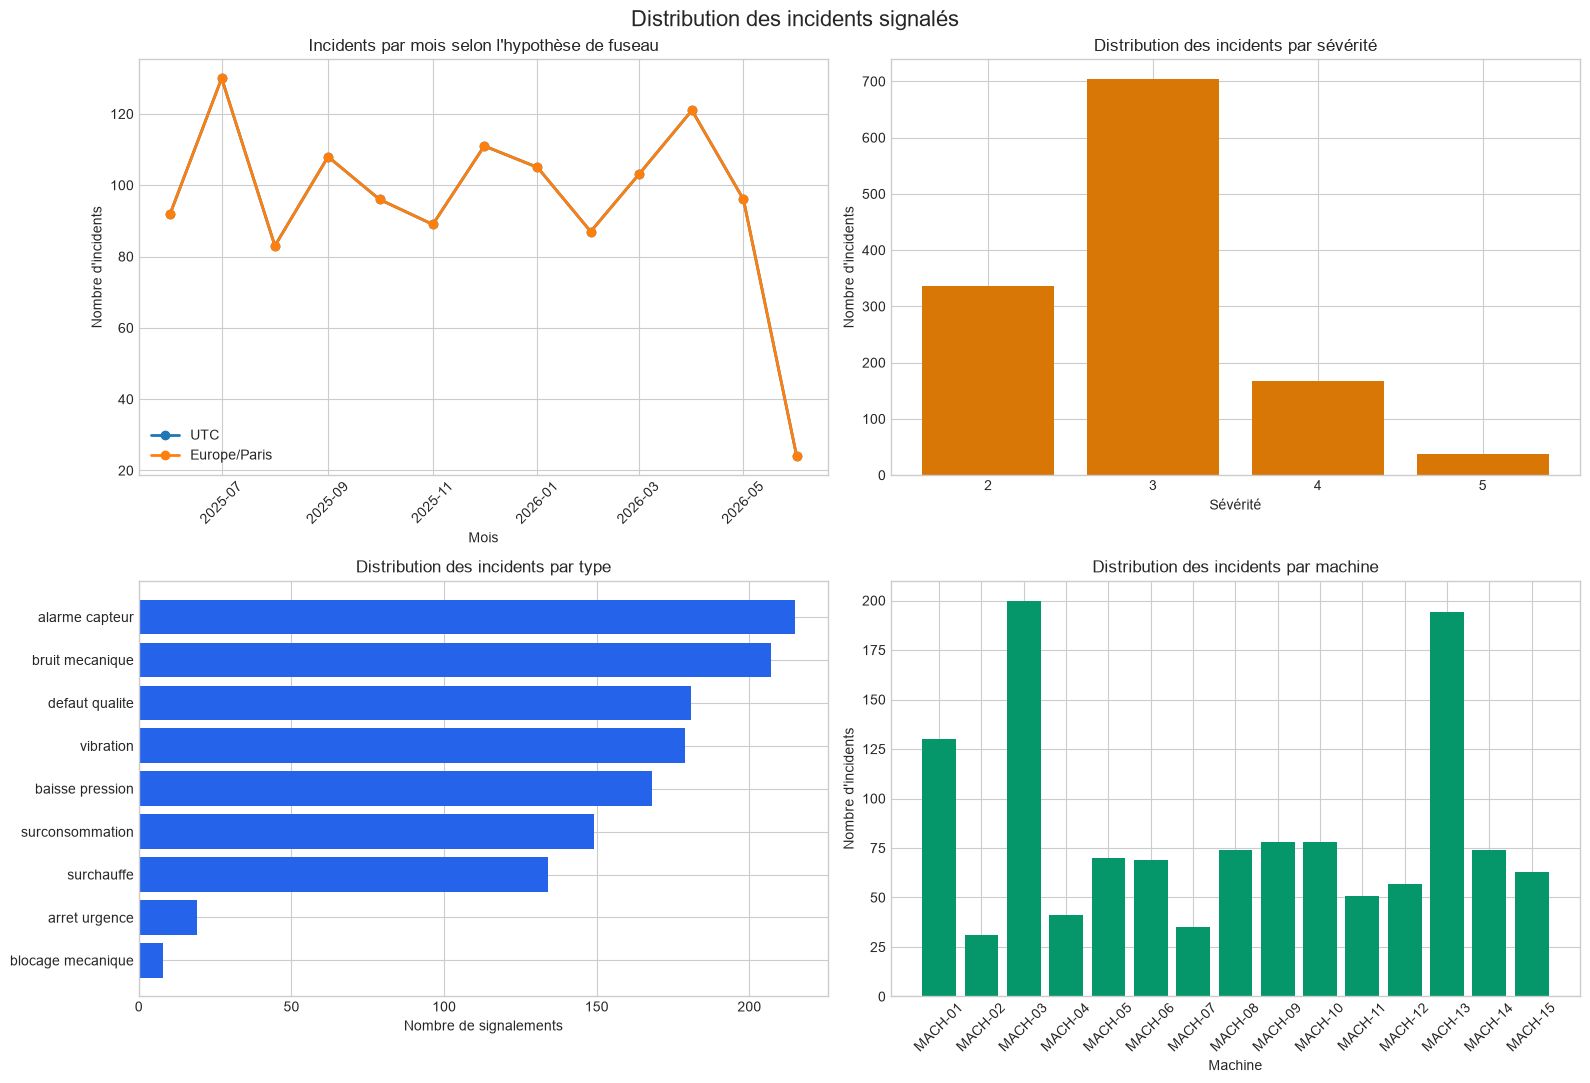

In [6]:
def mois_sans_fuseau(horodatages):
    # Convertit les horodatages en débuts de mois comparables et affichables.
    return horodatages.dt.tz_localize(None).dt.to_period("M").dt.start_time


fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for nom, donnees in scenarios.items():
    incidents_par_mois = (
        mois_sans_fuseau(donnees["incidents"])
        .value_counts()
        .sort_index()
    )
    axes[0, 0].plot(
        incidents_par_mois.index,
        incidents_par_mois.values,
        marker="o",
        linewidth=2,
        label=nom,
    )

axes[0, 0].set_title("Incidents par mois selon l'hypothèse de fuseau")
axes[0, 0].set_xlabel("Mois")
axes[0, 0].set_ylabel("Nombre d'incidents")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

incidents_par_severite = incidents_silver["severity"].value_counts().sort_index()
axes[0, 1].bar(
    incidents_par_severite.index.astype(str),
    incidents_par_severite.values,
    color="#d97706",
)
axes[0, 1].set_title("Distribution des incidents par sévérité")
axes[0, 1].set_xlabel("Sévérité")
axes[0, 1].set_ylabel("Nombre d'incidents")

incidents_par_type = (
    incidents_silver[colonnes_types_incident]
    .sum()
    .sort_values()
)
libelles_types = [nom.removeprefix("type_").replace("_", " ") for nom in incidents_par_type.index]
axes[1, 0].barh(libelles_types, incidents_par_type.values, color="#2563eb")
axes[1, 0].set_title("Distribution des incidents par type")
axes[1, 0].set_xlabel("Nombre de signalements")

incidents_par_machine = incidents_silver["machine_id"].value_counts().sort_index()
axes[1, 1].bar(incidents_par_machine.index, incidents_par_machine.values, color="#059669")
axes[1, 1].set_title("Distribution des incidents par machine")
axes[1, 1].set_xlabel("Machine")
axes[1, 1].set_ylabel("Nombre d'incidents")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle("Distribution des incidents signalés", fontsize=16)
fig.tight_layout()
plt.show()

## 6. Aligner les incidents et les maintenances par machine et par mois

L'**alignement temporel** consiste à placer les deux sources sur les mêmes machines et les mêmes périodes. Nous construisons donc toutes les combinaisons `machine × mois`, y compris lorsqu'aucun événement n'a eu lieu. Remplir ces absences par zéro évite de supprimer silencieusement les périodes calmes.

Le **coefficient de Pearson** mesure une relation linéaire. Le coefficient de **Spearman**, retenu principalement ici, compare le rang des valeurs et convient mieux à des comptes discrets et asymétriques.

La cellule suivante produit un nuage de points pour chaque scénario. La taille d'un point indique combien de couples `machine × mois` possèdent exactement les mêmes nombres d'incidents et de maintenances. Le troisième graphe mesure la corrélation lorsque les incidents sont décalés de trois mois avant à trois mois après la maintenance.

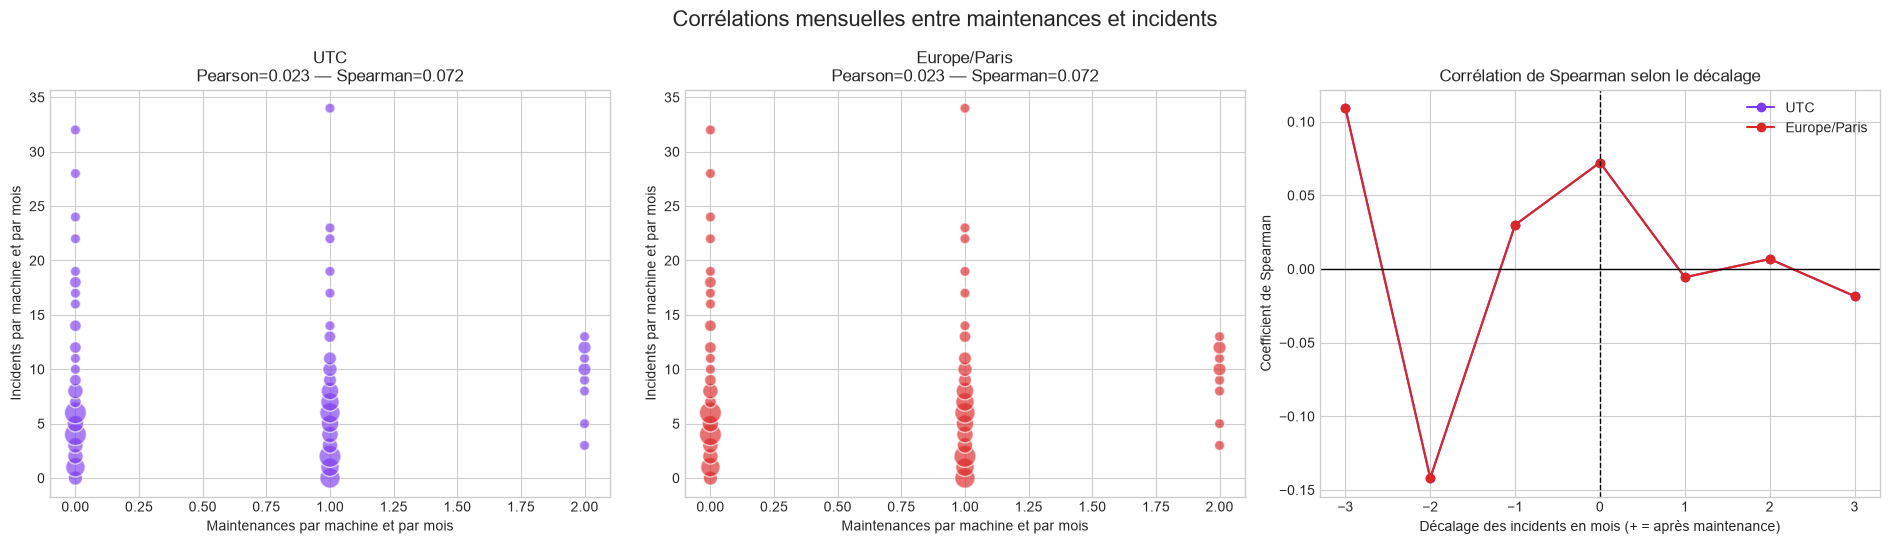

╭──────────────┬─────────────────────────────┬───────────┬────────────╮
│ scénario     │   observations machine-mois │   Pearson │   Spearman │
├──────────────┼─────────────────────────────┼───────────┼────────────┤
│ UTC          │                         180 │    0.0232 │     0.0723 │
│ Europe/Paris │                         180 │    0.0232 │     0.0723 │
╰──────────────┴─────────────────────────────┴───────────┴────────────╯


In [7]:
def construire_panel_mensuel(nom_scenario):
    donnees = scenarios[nom_scenario]
    incidents = incidents_silver[["machine_id"]].copy()
    incidents["timestamp"] = donnees["incidents"]
    maintenances = machines_analyse[["machine_code", "maintenance_type"]].copy()
    maintenances["timestamp"] = donnees["maintenances"]

    debut_commun = max(incidents["timestamp"].min(), maintenances["timestamp"].min())
    fin_commune = min(incidents["timestamp"].max(), maintenances["timestamp"].max())
    incidents = incidents[incidents["timestamp"].between(debut_commun, fin_commune)].copy()
    maintenances = maintenances[maintenances["timestamp"].between(debut_commun, fin_commune)].copy()

    incidents["mois"] = mois_sans_fuseau(incidents["timestamp"])
    maintenances["mois"] = mois_sans_fuseau(maintenances["timestamp"])

    machines = sorted(set(incidents["machine_id"]) & set(maintenances["machine_code"]))
    mois = pd.date_range(
        start=incidents["mois"].min(),
        end=incidents["mois"].max(),
        freq="MS",
    )
    index_complet = pd.MultiIndex.from_product(
        [machines, mois], names=["machine_id", "mois"]
    )

    comptes_incidents = incidents.groupby(["machine_id", "mois"]).size().rename("incidents")
    comptes_maintenances = (
        maintenances.groupby(["machine_code", "mois"]).size().rename("maintenances")
    )
    comptes_maintenances.index = comptes_maintenances.index.set_names(["machine_id", "mois"])

    panel = pd.concat([comptes_incidents, comptes_maintenances], axis=1)
    panel = panel.reindex(index_complet, fill_value=0).fillna(0).astype(int)
    return panel


panels_mensuels = {
    nom: construire_panel_mensuel(nom)
    for nom in scenarios
}


def correlations(panel):
    pearson = panel["maintenances"].corr(panel["incidents"])
    spearman = panel["maintenances"].rank().corr(panel["incidents"].rank())
    return pearson, spearman


fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
couleurs = {"UTC": "#7c3aed", "Europe/Paris": "#dc2626"}

for axe, (nom, panel) in zip(axes[:2], panels_mensuels.items()):
    points = (
        panel.reset_index()
        .groupby(["maintenances", "incidents"])
        .size()
        .reset_index(name="fréquence")
    )
    pearson, spearman = correlations(panel)
    axe.scatter(
        points["maintenances"],
        points["incidents"],
        s=35 + 18 * points["fréquence"],
        alpha=0.65,
        color=couleurs[nom],
        edgecolor="white",
    )
    axe.set_title(f"{nom}\nPearson={pearson:.3f} — Spearman={spearman:.3f}")
    axe.set_xlabel("Maintenances par machine et par mois")
    axe.set_ylabel("Incidents par machine et par mois")

for nom, panel in panels_mensuels.items():
    decalages = range(-3, 4)
    coefficients = []
    for decalage in decalages:
        incidents_decales = panel.groupby(level="machine_id")["incidents"].shift(-decalage)
        masque = incidents_decales.notna()
        coefficient = (
            panel.loc[masque, "maintenances"].rank().corr(incidents_decales[masque].rank())
        )
        coefficients.append(coefficient)
    axes[2].plot(decalages, coefficients, marker="o", label=nom, color=couleurs[nom])

axes[2].axhline(0, color="black", linewidth=1)
axes[2].axvline(0, color="black", linewidth=1, linestyle="--")
axes[2].set_title("Corrélation de Spearman selon le décalage")
axes[2].set_xlabel("Décalage des incidents en mois (+ = après maintenance)")
axes[2].set_ylabel("Coefficient de Spearman")
axes[2].legend()

fig.suptitle("Corrélations mensuelles entre maintenances et incidents", fontsize=16)
fig.tight_layout()
plt.show()

resume_correlations = []
for nom, panel in panels_mensuels.items():
    pearson, spearman = correlations(panel)
    resume_correlations.append(
        {
            "scénario": nom,
            "observations machine-mois": len(panel),
            "Pearson": round(pearson, 4),
            "Spearman": round(spearman, 4),
        }
    )

resume_correlations = pd.DataFrame(resume_correlations)
print(tabulate(resume_correlations, headers="keys", tablefmt="rounded_outline", showindex=False))

## 7. Replacer chaque maintenance au centre d'une fenêtre de 30 jours

Une agrégation mensuelle peut séparer artificiellement deux événements situés de part et d'autre d'un changement de mois. L'**analyse événementielle** évite cette limite : chaque maintenance devient le temps zéro et nous comptons les incidents de la même machine pendant les 30 jours précédents et suivants.

Le nuage de points place le nombre d'incidents avant la maintenance sur l'axe horizontal et le nombre après sur l'axe vertical :

- sous la diagonale, il y a moins d'incidents après qu'avant ;
- au-dessus, il y en a davantage après ;
- sur la diagonale, les deux comptes sont identiques.

Cette comparaison reste descriptive. Une baisse après maintenance peut être associée à l'intervention sans prouver que celle-ci en est l'unique cause.

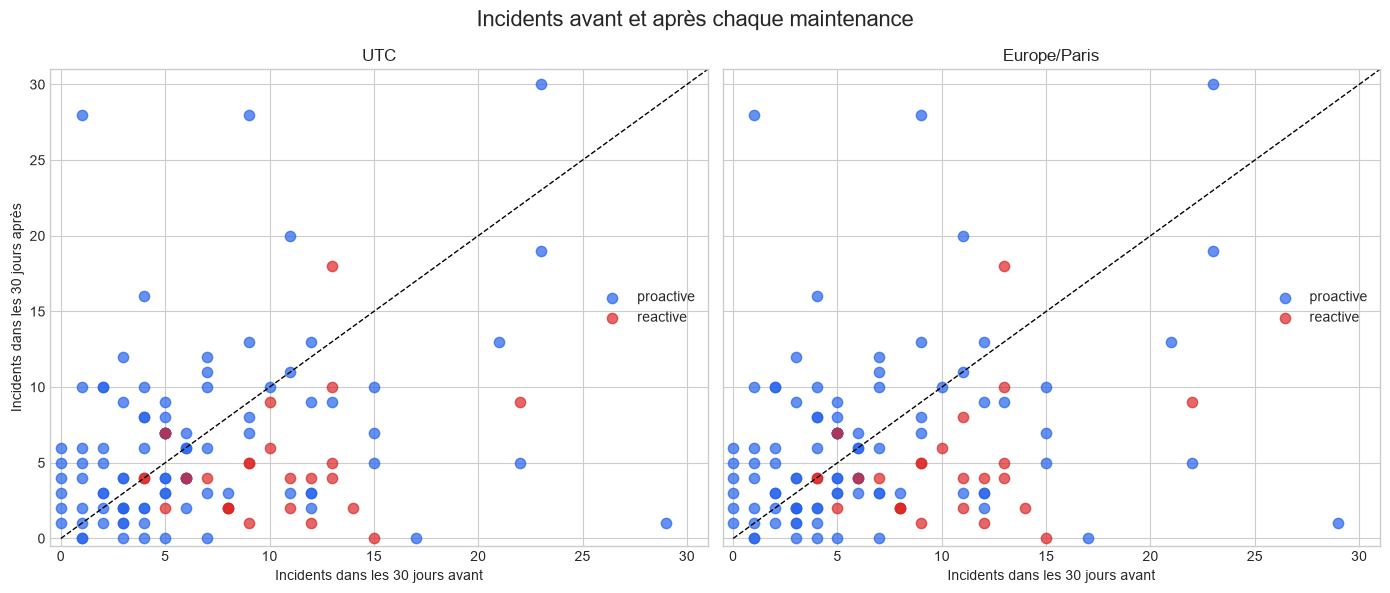

╭──────────────┬────────────────────┬───────────────────────┬───────────────────────╮
│ scénario     │ maintenance_type   │   incidents_avant_30j │   incidents_apres_30j │
├──────────────┼────────────────────┼───────────────────────┼───────────────────────┤
│ UTC          │ proactive          │                  6.33 │                  6.37 │
│ UTC          │ reactive           │                 10.04 │                  4.64 │
│ Europe/Paris │ proactive          │                  6.34 │                  6.37 │
│ Europe/Paris │ reactive           │                 10.08 │                  4.6  │
╰──────────────┴────────────────────┴───────────────────────┴───────────────────────╯


In [8]:
FENETRE_JOURS = 30


def construire_fenetres_evenements(nom_scenario):
    incidents = pd.DataFrame(
        {
            "machine_id": incidents_silver["machine_id"],
            "timestamp": scenarios[nom_scenario]["incidents"],
        }
    )
    maintenances = machines_analyse[
        ["maintenance_id", "machine_code", "maintenance_type"]
    ].copy()
    maintenances["timestamp"] = scenarios[nom_scenario]["maintenances"]

    lignes = []
    fenetre = pd.Timedelta(days=FENETRE_JOURS)
    for maintenance in maintenances.itertuples(index=False):
        incidents_machine = incidents.loc[
            incidents["machine_id"].eq(maintenance.machine_code), "timestamp"
        ]
        avant = incidents_machine.between(
            maintenance.timestamp - fenetre,
            maintenance.timestamp,
            inclusive="left",
        ).sum()
        apres = incidents_machine.between(
            maintenance.timestamp,
            maintenance.timestamp + fenetre,
            inclusive="right",
        ).sum()
        lignes.append(
            {
                "maintenance_id": maintenance.maintenance_id,
                "machine_id": maintenance.machine_code,
                "maintenance_type": maintenance.maintenance_type,
                "incidents_avant_30j": int(avant),
                "incidents_apres_30j": int(apres),
            }
        )
    return pd.DataFrame(lignes)


fenetres_evenements = {
    nom: construire_fenetres_evenements(nom)
    for nom in scenarios
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
couleurs_maintenance = {"proactive": "#2563eb", "reactive": "#dc2626"}

limite = max(
    fenetre[["incidents_avant_30j", "incidents_apres_30j"]].to_numpy().max()
    for fenetre in fenetres_evenements.values()
) + 1

for axe, (nom, fenetre) in zip(axes, fenetres_evenements.items()):
    for type_maintenance, groupe in fenetre.groupby("maintenance_type"):
        axe.scatter(
            groupe["incidents_avant_30j"],
            groupe["incidents_apres_30j"],
            alpha=0.7,
            s=55,
            label=type_maintenance,
            color=couleurs_maintenance[type_maintenance],
        )
    axe.plot([0, limite], [0, limite], linestyle="--", color="black", linewidth=1)
    axe.set_xlim(-0.5, limite)
    axe.set_ylim(-0.5, limite)
    axe.set_title(nom)
    axe.set_xlabel("Incidents dans les 30 jours avant")
    axe.legend()

axes[0].set_ylabel("Incidents dans les 30 jours après")
fig.suptitle("Incidents avant et après chaque maintenance", fontsize=16)
fig.tight_layout()
plt.show()

resume_fenetres = []
for nom, fenetre in fenetres_evenements.items():
    moyennes = (
        fenetre.groupby("maintenance_type")
        [["incidents_avant_30j", "incidents_apres_30j"]]
        .mean()
        .round(2)
        .reset_index()
    )
    moyennes.insert(0, "scénario", nom)
    resume_fenetres.append(moyennes)

resume_fenetres = pd.concat(resume_fenetres, ignore_index=True)
print(tabulate(resume_fenetres, headers="keys", tablefmt="rounded_outline", showindex=False))

## 8. Auditer les liens explicites entre maintenance réactive et incident

`machine.csv` contient `related_incident_id`. Cette clé propose un rapprochement direct avec `incident_id`, mais sa cohérence doit être vérifiée avant utilisation.

La cellule suivante vérifie uniquement :

- combien de maintenances possèdent un lien ;
- si l'incident existe ;
- si les deux événements concernent la même machine ;
- le délai uniquement pour les liens dont la machine est cohérente.

Aucune donnée opérateur ni aucun commentaire n'est affiché.

In [9]:
liens = machines_analyse.loc[
    machines_analyse["related_incident_id"].notna(),
    [
        "maintenance_id",
        "machine_code",
        "maintenance_type",
        "related_incident_id",
        "maintenance_at_utc",
    ],
].merge(
    pd.DataFrame(
        {
            "incident_id": incidents_silver["incident_id"],
            "machine_id": incidents_silver["machine_id"],
            "incident_at_utc_hypothese": scenarios["UTC"]["incidents"],
        }
    ),
    left_on="related_incident_id",
    right_on="incident_id",
    how="left",
    validate="many_to_one",
)

liens["meme_machine"] = liens["machine_code"].eq(liens["machine_id"])
assert liens["incident_id"].notna().all()
assert liens["maintenance_type"].eq("reactive").all()

liens_coherents = liens.loc[liens["meme_machine"]].copy()
liens_coherents["delai_jours"] = (
    liens_coherents["maintenance_at_utc"]
    - liens_coherents["incident_at_utc_hypothese"]
).dt.total_seconds() / 86_400

rapport_liens = pd.DataFrame(
    {
        "indicateur": [
            "Liens renseignés",
            "Incidents retrouvés",
            "Liens sur la même machine",
            "Liens avec machines différentes",
            "Délai du lien cohérent (jours)",
        ],
        "valeur": [
            len(liens),
            liens["incident_id"].notna().sum(),
            liens["meme_machine"].sum(),
            liens["meme_machine"].eq(False).sum(),
            round(liens_coherents["delai_jours"].iloc[0], 1),
        ],
    }
)

print(tabulate(rapport_liens, headers="keys", tablefmt="rounded_outline", showindex=False))

╭─────────────────────────────────┬──────────╮
│ indicateur                      │   valeur │
├─────────────────────────────────┼──────────┤
│ Liens renseignés                │     25   │
│ Incidents retrouvés             │     25   │
│ Liens sur la même machine       │      1   │
│ Liens avec machines différentes │     24   │
│ Délai du lien cohérent (jours)  │     54.6 │
╰─────────────────────────────────┴──────────╯


## 9. Retracer l'histoire sur une chronologie commune

La chronologie suivante utilise le scénario `Europe/Paris` pour l'affichage. Chaque ligne correspond à une machine :

- un cercle représente un incident ; sa taille augmente avec la sévérité ;
- un triangle bleu représente une maintenance proactive ;
- un triangle rouge représente une maintenance réactive.

Le graphe permet de repérer visuellement les regroupements d'incidents et la position des maintenances, sans afficher d'information sur les opérateurs.

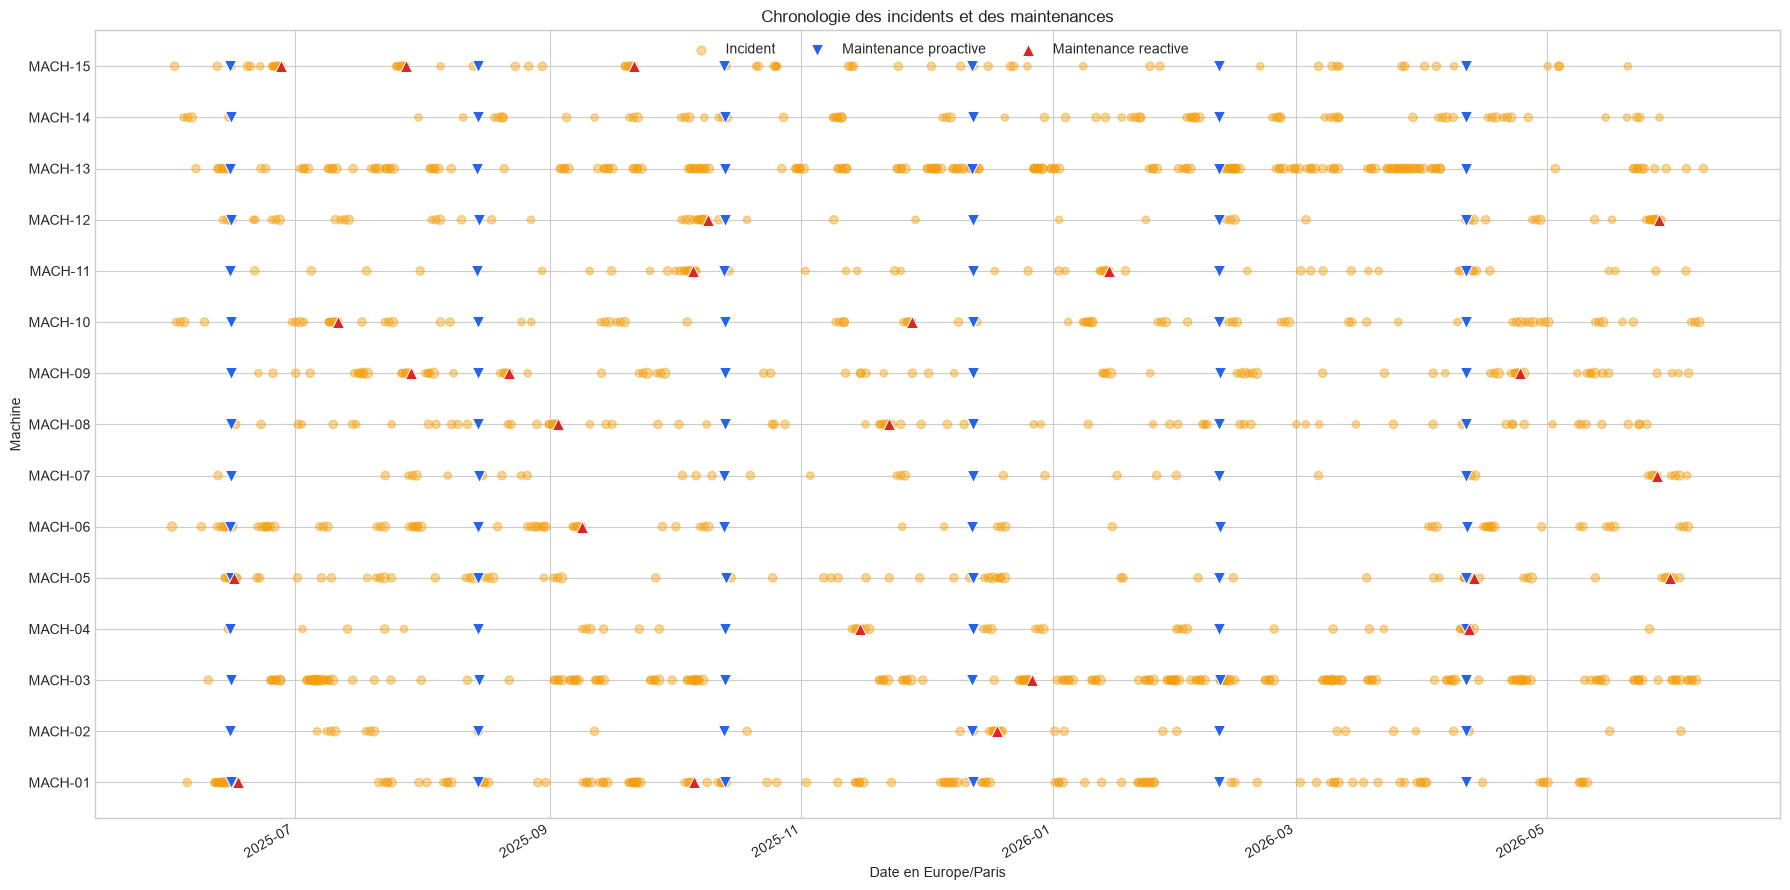

In [10]:
ordre_machines = sorted(incidents_silver["machine_id"].unique())
position_machine = {machine: position for position, machine in enumerate(ordre_machines)}

fig, axe = plt.subplots(figsize=(18, 9))

positions_incidents = incidents_silver["machine_id"].map(position_machine)
axe.scatter(
    scenarios["Europe/Paris"]["incidents"],
    positions_incidents,
    s=12 + incidents_silver["severity"].astype(int) * 8,
    alpha=0.42,
    color="#f59e0b",
    label="Incident",
)

for type_maintenance, groupe in machines_analyse.groupby("maintenance_type"):
    positions = groupe["machine_code"].map(position_machine)
    axe.scatter(
        scenarios["Europe/Paris"]["maintenances"].loc[groupe.index],
        positions,
        marker="v" if type_maintenance == "proactive" else "^",
        s=75,
        color=couleurs_maintenance[type_maintenance],
        edgecolor="white",
        linewidth=0.7,
        label=f"Maintenance {type_maintenance}",
    )

axe.set_yticks(range(len(ordre_machines)), ordre_machines)
axe.set_xlabel("Date en Europe/Paris")
axe.set_ylabel("Machine")
axe.set_title("Chronologie des incidents et des maintenances")
axe.legend(loc="upper center", ncol=3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 10. Interpréter les résultats sans inventer de causalité

La cellule suivante rassemble les conclusions calculées : corrélation mensuelle, effet du fuseau sur les comptes avant/après et variation moyenne observée autour des maintenances.

Une corrélation proche de zéro indique une association faible dans cette représentation. Une différence avant/après décrit les données observées, mais d'autres facteurs peuvent intervenir : production, âge de la machine, criticité, saison, fréquence d'utilisation ou stratégie de maintenance.

Le résultat attendu est une synthèse textuelle permettant de défendre les choix pendant une soutenance.

In [11]:
print("SYNTHÈSE DE L'ANALYSE")
print("=" * 72)

for ligne in resume_correlations.itertuples(index=False):
    print(
        f"- {ligne.scénario}: corrélation mensuelle de Spearman = "
        f"{ligne.Spearman:.4f} sur {ligne[1]} observations machine-mois."
    )

for nom, fenetre in fenetres_evenements.items():
    difference = (
        fenetre["incidents_apres_30j"] - fenetre["incidents_avant_30j"]
    ).mean()
    print(
        f"- {nom}: variation moyenne après - avant sur ±30 jours = "
        f"{difference:.2f} incident(s) par maintenance."
    )

comparaison_fenetres = fenetres_evenements["UTC"].merge(
    fenetres_evenements["Europe/Paris"],
    on=["maintenance_id", "machine_id", "maintenance_type"],
    suffixes=("_utc", "_paris"),
    validate="one_to_one",
)
fenetres_modifiees = (
    comparaison_fenetres["incidents_avant_30j_utc"].ne(
        comparaison_fenetres["incidents_avant_30j_paris"]
    )
    | comparaison_fenetres["incidents_apres_30j_utc"].ne(
        comparaison_fenetres["incidents_apres_30j_paris"]
    )
).sum()

print(
    f"- Le choix du fuseau modifie les comptes avant/après pour "
    f"{fenetres_modifiees} maintenance(s) sur {len(comparaison_fenetres)}."
)
print(
    f"- Alerte qualité : {liens['meme_machine'].eq(False).sum()} lien(s) "
    f"related_incident_id sur {len(liens)} associent des machines différentes ; "
    "ces liens ne sont pas utilisés pour l'alignement principal."
)
print(
    "- Ces résultats décrivent une association temporelle ; ils ne démontrent "
    "pas une relation de cause à effet."
)

SYNTHÈSE DE L'ANALYSE
- UTC: corrélation mensuelle de Spearman = 0.0723 sur 180 observations machine-mois.
- Europe/Paris: corrélation mensuelle de Spearman = 0.0723 sur 180 observations machine-mois.
- UTC: variation moyenne après - avant sur ±30 jours = -1.15 incident(s) par maintenance.
- Europe/Paris: variation moyenne après - avant sur ±30 jours = -1.17 incident(s) par maintenance.
- Le choix du fuseau modifie les comptes avant/après pour 3 maintenance(s) sur 115.
- Alerte qualité : 24 lien(s) related_incident_id sur 25 associent des machines différentes ; ces liens ne sont pas utilisés pour l'alignement principal.
- Ces résultats décrivent une association temporelle ; ils ne démontrent pas une relation de cause à effet.


## Analyse des résultats — l'histoire racontée par les graphes

### 1. Les incidents forment un bruit de fond régulier, avec quelques périodes plus chargées

La courbe mensuelle montre que les incidents ne sont pas concentrés dans un épisode unique : ils accompagnent toute l'année observée. Parmi les mois complets, juillet 2025 atteint le niveau le plus élevé avec **130 incidents**, puis avril 2026 avec **121 incidents**. Les niveaux les plus faibles apparaissent en août 2025 avec **83 incidents** et en février 2026 avec **87 incidents**.

Le dernier point, juin 2026 avec **24 incidents**, ne représente que les huit premiers jours du mois. Il ne doit donc pas être comparé directement aux mois complets. Cette précaution évite de raconter artificiellement une baisse en fin de période.

Les courbes UTC et `Europe/Paris` se superposent à l'échelle mensuelle : le décalage d'une ou deux heures ne suffit pas à déplacer un nombre visible d'incidents d'un mois vers un autre.

### 2. La majorité des incidents est de sévérité intermédiaire

La sévérité 3 représente **704 incidents sur 1 245**, soit environ **56,5 %** du dataset. Les incidents de sévérité 5 sont beaucoup plus rares avec **38 cas**. L'histoire générale n'est donc pas celle d'une succession d'événements extrêmes, mais celle d'un volume important d'incidents intermédiaires, ponctué de quelques événements critiques.

Les types les plus souvent signalés sont l'**alarme capteur** avec 215 occurrences et le **bruit mécanique** avec 207 occurrences. Le **blocage mécanique** et l'**arrêt d'urgence** sont rares, avec respectivement 8 et 19 occurrences. Comme plusieurs indicateurs `type_*` peuvent être vrais sur une même ligne, leurs nombres ne doivent pas être additionnés pour retrouver les 1 245 incidents.

### 3. La charge d'incidents est très différente selon les machines

`MACH-03` totalise **200 incidents**, `MACH-13` en totalise **194** et `MACH-01` en totalise **130**. Les deux premières machines concentrent à elles seules près de **31,6 %** des incidents. La chronologie confirme que leurs signalements sont nombreux sur l'ensemble de la période, et non limités à un seul pic isolé.

Ce constat en fait des candidates prioritaires pour une analyse complémentaire : âge, modèle, ligne de production, criticité, capacité ou conditions d'utilisation. Il ne permet pas encore d'affirmer qu'elles sont moins fiables, car le dataset ne donne pas leur volume réel de production pendant chaque période.

### 4. À l'échelle mensuelle, maintenance et incidents évoluent presque indépendamment

Le nuage de points ne dessine pas de pente claire. Le coefficient de Pearson vaut environ **0,023** et celui de Spearman environ **0,072** dans les deux scénarios horaires. Ces valeurs proches de zéro indiquent qu'un mois comportant davantage de maintenances n'est pas systématiquement associé à un mois comportant davantage ou moins d'incidents.

Les corrélations décalées entre trois mois avant et trois mois après restent faibles, approximativement entre **−0,15 et +0,11**. Aucun décalage ne révèle donc une relation temporelle stable et forte. Le résultat ne signifie pas que les maintenances sont inutiles : leur effet peut être local à une machine, dépendre du composant traité ou être masqué par des rythmes de production différents.

### 5. Les fenêtres de 30 jours racontent deux histoires de maintenance différentes

Autour des maintenances **proactives**, le nombre moyen d'incidents reste presque stable : environ **6,3 avant et 6,4 après**. Leur rôle peut justement être de prévenir une dégradation plutôt que de répondre à une hausse visible.

Autour des maintenances **réactives**, environ **10 incidents** sont observés avant contre **4,6 après**. Le graphe raconte donc une séquence plausible : une période chargée en incidents est suivie d'une intervention, puis d'une période plus calme.

Cette séquence n'établit toutefois pas une causalité. Les maintenances réactives sont sélectionnées parce qu'un problème a déjà été observé ; une partie de la baisse peut venir d'un retour naturel vers un niveau habituel, d'un changement de production ou d'une autre intervention. De plus, seules 25 maintenances sont réactives.

### 6. Les données imposent de préférer l'alignement par machine aux liens déclarés

Les 25 valeurs de `related_incident_id` retrouvent bien un incident, mais **24 associent des machines différentes**. Elles ne peuvent donc pas servir à raconter une relation fiable entre un incident précis et une maintenance précise. L'analyse principale utilise à la place une règle reproductible : même machine et même fenêtre temporelle.

Le choix du fuseau ne modifie que **3 fenêtres sur 115**. La conclusion générale est donc robuste à cette incertitude, même si ces trois cas montrent pourquoi il faut expliciter l'hypothèse horaire.

### Conclusion métier

Les graphes racontent une activité industrielle marquée par des incidents récurrents, principalement de sévérité intermédiaire, avec une concentration notable sur `MACH-03` et `MACH-13`. Les maintenances proactives s'inscrivent dans un contexte relativement stable. Les maintenances réactives surviennent après des périodes plus chargées et sont suivies, en moyenne, d'une diminution des incidents. Cette dernière observation constitue une **hypothèse à approfondir**, pas une preuve d'efficacité causale. Pour aller plus loin, il faudrait intégrer le volume de production, le temps de fonctionnement, le composant entretenu et éventuellement comparer plusieurs fenêtres temporelles.

## 11. Validation finale

Les contrôles finaux vérifient les conditions de réussite du TP :

- les deux sources Bronze possèdent toujours leur empreinte initiale ;
- le Silver contient autant de lignes que le Bronze incidents ;
- les trois colonnes humaines sont absentes du fichier produit ;
- les machines des deux sources correspondent ;
- les deux scénarios produisent un panel mensuel complet ;
- les 115 maintenances sont présentes dans chaque analyse événementielle.

Si une assertion échoue, l'exécution s'arrête avec un message précis. Si toutes passent, le notebook affiche `VALIDATION : OK`.

In [12]:
empreintes_bronze_finales = {
    chemin.name: empreinte_fichier(chemin)
    for chemin in (CHEMIN_MACHINES, CHEMIN_INCIDENTS)
}

assert empreintes_bronze_finales == empreintes_bronze_initiales
assert len(silver_relu) == len(incidents_bronze) == 1245
assert not set(colonnes_supprimees) & set(silver_relu.columns)
assert set(machines_analyse["machine_code"]) == set(incidents_silver["machine_id"])
assert all(len(panel) == 180 for panel in panels_mensuels.values())
assert all(len(fenetre) == len(machines_analyse) == 115 for fenetre in fenetres_evenements.values())
assert len(liens) == 25

print("VALIDATION : OK")
print("- Sources Bronze inchangées")
print("- Silver produit et relu sans les colonnes humaines")
print("- Deux scénarios horaires calculés")
print("- Distributions, corrélations, fenêtres ±30 jours et chronologie générées")

VALIDATION : OK
- Sources Bronze inchangées
- Silver produit et relu sans les colonnes humaines
- Deux scénarios horaires calculés
- Distributions, corrélations, fenêtres ±30 jours et chronologie générées
